In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import root_scalar, fsolve

In [2]:
c_0 = 2
c_1 = 0.185

k_3 = 0.1

v_1 = 7.11 / (1 + c_1)
v_2 = 0.13035 / (1 + c_1)
v_3 = 9 * k_3

#C_0 = 16.8776

IP_concentration = 0.4

a_1 = 40 / k_3
a_2 = 0.02 / k_3
a_3 = 40 / k_3
a_4 = 0.02 / k_3
a_5 = 2 / k_3

b_1 = 52
b_2 = 0.2098
b_3 = 377.36
b_4 = 0.0289
b_5 = 1.6468

# d_i = b_i / a_i
d_1 = b_1 / a_1
d_2 = b_2 / a_2
d_3 = b_3 / a_3
d_4 = b_4 / a_4
d_5 = b_5 / a_5

def q2(ip):
    return d_2 * (IP_concentration + d_1) / (IP_concentration + d_3)

def m_inf(Ca, ip):
    return (ip / (ip + d_1)) * (Ca / (Ca + d_5))

def Ca_er(Ca):
    return (c_0 - Ca) / c_1

def h_inf(Ca, ip):
    return q2(ip) / (q2(ip) + Ca)

def t_h(Ca, ip):
    return 1 / (a_2 * (q2(ip) + Ca))

def dC(Ca, h, ip):
    return -c_1 * v_1 * m_inf(Ca, ip)**3 * h**3 * (Ca - Ca_er(Ca)) - c_1 * v_2 * (Ca - Ca_er(Ca)) - v_3 * Ca**2 / (k_3**2 + Ca**2)

def dh(Ca, h, ip):
    return (h_inf(Ca, ip) - h) / t_h(Ca, ip)

def dS(s, ip):
    return [dC(s[0], s[1], ip), dh(s[0], s[1], ip)]

Text(0.5, 0, 'Time (seconds)')

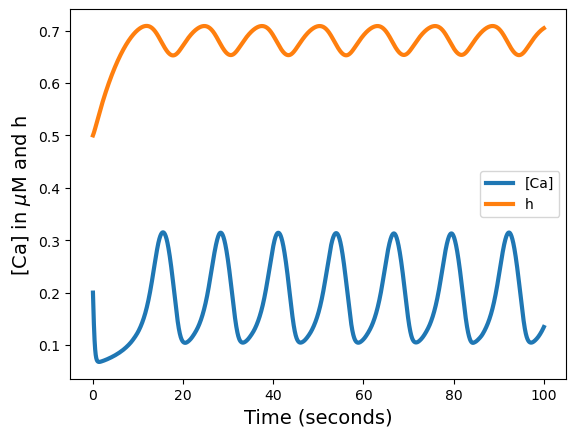

In [3]:
Ca_0 = 0.2
h_0 = 0.5

IP_concentration = 0.4

TIME_INTERVAL = [0, 100]
TIME_PTS = np.linspace(TIME_INTERVAL[0], TIME_INTERVAL[1], 10000)
soln = solve_ivp(lambda t, s : dS(s, IP_concentration), TIME_INTERVAL, [Ca_0, h_0], t_eval=TIME_PTS)
plt.plot(TIME_PTS, soln.y[0,:], linewidth=3, label="[Ca]")
plt.plot(TIME_PTS, soln.y[1,:], linewidth=3, label="h")
plt.legend()
plt.ylabel("[Ca] in $\\mu$M and h", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=14)

Text(0.5, 0, '[$IP_3$] in $\\mu$M')

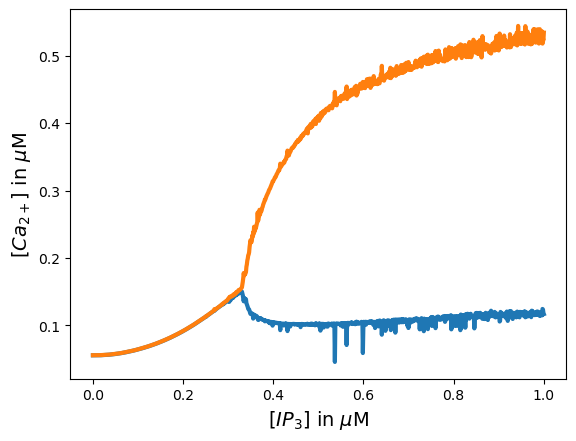

In [4]:
Ca_0 = 0.2
h_0 = 0.5

TIME_INTERVAL = [0, 1000]
TIME_PTS = np.linspace(TIME_INTERVAL[0], TIME_INTERVAL[1], 1000)

minimums = []
maximums = []

IP_concentrations_count = 1000
IP_concentrations = np.linspace(0, 1, IP_concentrations_count)

for i in range(IP_concentrations_count):
    soln = solve_ivp(lambda t, s : dS(s, IP_concentrations[i]), TIME_INTERVAL, [Ca_0, h_0], t_eval=TIME_PTS)
    min_ca = np.min(soln.y[0,-100:])
    max_ca = np.max(soln.y[0,-100:])
    minimums.append(min_ca)
    maximums.append(max_ca)

plt.plot(IP_concentrations, minimums, linewidth=3)
plt.plot(IP_concentrations, maximums, linewidth=3)
plt.ylabel("[$Ca_{2+}$] in $\\mu$M", fontsize=14)
plt.xlabel("[$IP_3$] in $\\mu$M", fontsize=14)

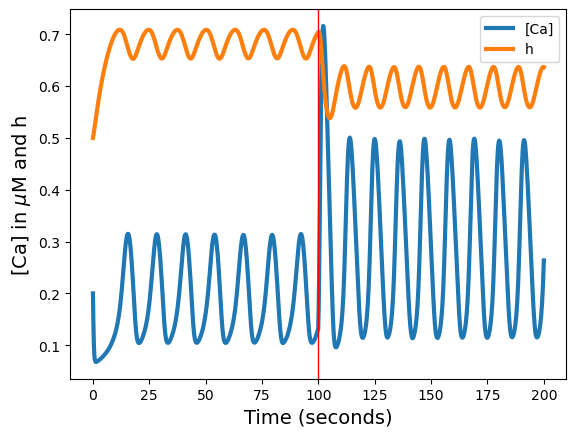

In [29]:
Ca_0 = 0.2
h_0 = 0.5

IP_concentration_early = 0.4
IP_concentration_late = 0.8
change_time = 100

def dSWithChange(t, s):
    if t < change_time:
        return dS(s, IP_concentration_early)
    else:
        return dS(s, IP_concentration_late)

TIME_INTERVAL = [0, 200]
TIME_PTS_COUNT = 1000
TIME_PTS = np.linspace(TIME_INTERVAL[0], TIME_INTERVAL[1], TIME_PTS_COUNT)
soln = solve_ivp(lambda t, s : dSWithChange(t, s), TIME_INTERVAL, [Ca_0, h_0], t_eval=TIME_PTS)
plt.plot(TIME_PTS, soln.y[0,:], linewidth=3, label="[Ca]")
plt.plot(TIME_PTS, soln.y[1,:], linewidth=3, label="h")
plt.legend()
plt.ylabel("[Ca] in $\\mu$M and h", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=14)
plt.axvline(change_time, color="red", linewidth=1)

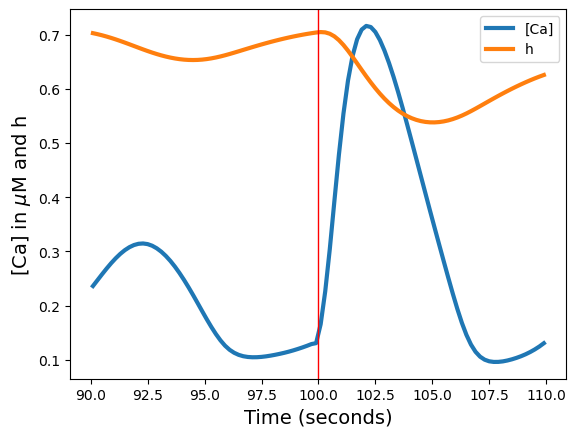

In [30]:
time_min = int(TIME_PTS_COUNT*0.45)
time_max = int(TIME_PTS_COUNT*0.55)
plt.plot(TIME_PTS[time_min:time_max], soln.y[0,time_min:time_max], linewidth=3, label="[Ca]")
plt.plot(TIME_PTS[time_min:time_max], soln.y[1,time_min:time_max], linewidth=3, label="h")
plt.legend()
plt.ylabel("[Ca] in $\\mu$M and h", fontsize=14)
plt.xlabel("Time (seconds)", fontsize=14)
plt.axvline(change_time, color="red", linewidth=1)